Causal graphs saved successfully!

Key insights:
- Left graph: Shows the misleading direct causal relationship
- Right graph: Reveals hot weather as the common cause (confounder)
- Ice cream sales and shark attacks are correlated but not causally related


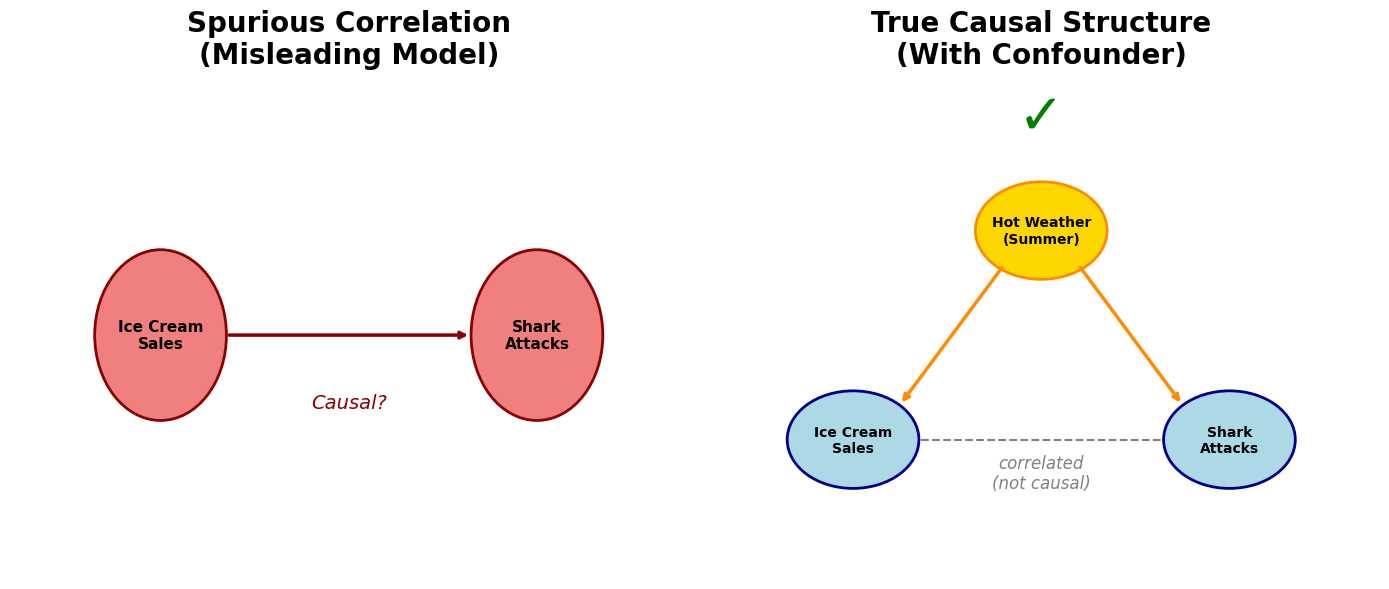

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyBboxPatch

# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Graph 1: Spurious correlation (no confounder shown)
G1 = nx.DiGraph()
G1.add_edge("Ice Cream\nSales", "Shark\nAttacks")

pos1 = {
    "Ice Cream\nSales": (0, 0),
    "Shark\nAttacks": (2, 0)
}

ax1.set_xlim(-0.8, 2.8)
ax1.set_ylim(-1, 1)
ax1.axis('off')
ax1.set_title("Spurious Correlation\n(Misleading Model)", fontsize=20, fontweight='bold', pad=20)

# Draw nodes for graph 1
for node, (x, y) in pos1.items():
    circle = plt.Circle((x, y), 0.35, color='lightcoral', ec='darkred', linewidth=2, zorder=2)
    ax1.add_patch(circle)
    ax1.text(x, y, node, ha='center', va='center', fontsize=11, fontweight='bold', zorder=3)

# Draw edge for graph 1
ax1.annotate('', xy=(1.65, 0), xytext=(0.35, 0),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='darkred'))
ax1.text(1, -0.3, "Causal?", ha='center', fontsize=14, style='italic', color='darkred')

# # Add question mark
# ax1.text(1, 0.8, "X", ha='center', fontsize=40, color='red')

# Graph 2: True causal structure with confounder
G2 = nx.DiGraph()
G2.add_edge("Hot Weather\n(Summer)", "Ice Cream\nSales")
G2.add_edge("Hot Weather\n(Summer)", "Shark\nAttacks")

pos2 = {
    "Hot Weather\n(Summer)": (1, 1),
    "Ice Cream\nSales": (0, -0.5),
    "Shark\nAttacks": (2, -0.5)
}

ax2.set_xlim(-0.8, 2.8)
ax2.set_ylim(-1.5, 2)
ax2.axis('off')
ax2.set_title("True Causal Structure\n(With Confounder)", fontsize=20, fontweight='bold', pad=20)

# Draw nodes for graph 2
for node, (x, y) in pos2.items():
    if "Hot Weather" in node:
        color = 'gold'
        edge_color = 'darkorange'
    else:
        color = 'lightblue'
        edge_color = 'darkblue'
    
    circle = plt.Circle((x, y), 0.35, color=color, ec=edge_color, linewidth=2, zorder=2)
    ax2.add_patch(circle)
    ax2.text(x, y, node, ha='center', va='center', fontsize=10, fontweight='bold', zorder=3)

# Draw edges for graph 2
# Hot Weather -> Ice Cream Sales
ax2.annotate('', xy=(0.25, -0.25), xytext=(0.8, 0.75),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='darkorange'))

# Hot Weather -> Shark Attacks
ax2.annotate('', xy=(1.75, -0.25), xytext=(1.2, 0.75),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='darkorange'))

# Dashed line showing correlation (not causation) between Ice Cream and Shark Attacks
ax2.plot([0.3, 1.7], [-0.5, -0.5], 'k--', lw=1.5, alpha=0.5, zorder=1)
ax2.text(1, -0.85, "correlated\n(not causal)", ha='center', fontsize=12, 
         style='italic', color='gray')

# Add checkmark
ax2.text(1, 1.7, "✓", ha='center', fontsize=40, color='green')

plt.tight_layout()
print("Causal graphs saved successfully!")
print("\nKey insights:")
print("- Left graph: Shows the misleading direct causal relationship")
print("- Right graph: Reveals hot weather as the common cause (confounder)")
print("- Ice cream sales and shark attacks are correlated but not causally related")

DAG saved successfully!

Key insights:
- Smoking and Genetics are independent causes
- Both directly increase lung cancer risk
- This is a 'collider' structure - lung cancer is the common effect
- Conditioning on lung cancer can create spurious association between smoking and genetics


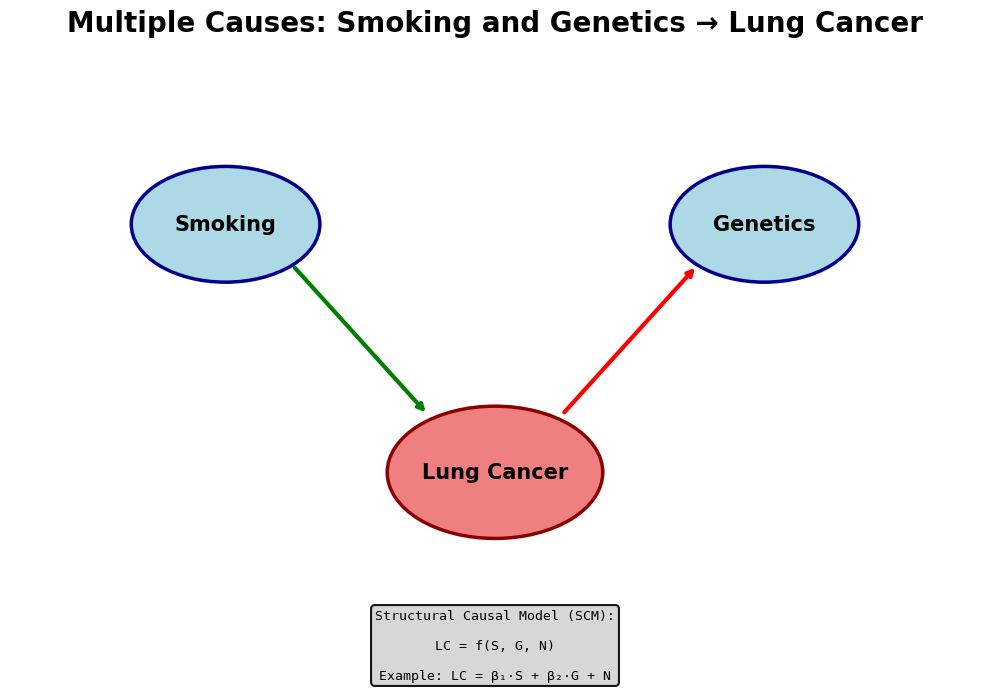

In [24]:
import matplotlib.pyplot as plt
import networkx as nx

# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Create the DAG
G = nx.DiGraph()
G.add_edge("Smoking", "Lung Cancer")
G.add_edge("Genetics", "Lung Cancer")

# Define positions for nodes
pos = {
    "Smoking": (0, 1),
    "Genetics": (2, 1),
    "Lung Cancer": (1, -0.5)
}

ax.set_xlim(-0.8, 2.8)
ax.set_ylim(-1.5, 2)
ax.axis('off')
ax.set_title("Multiple Causes: Smoking and Genetics → Lung Cancer", 
             fontsize=20, fontweight='bold', pad=20)

# Draw nodes with different colors for causes vs outcome
for node, (x, y) in pos.items():
    if node == "Lung Cancer":
        color = 'lightcoral'
        edge_color = 'darkred'
        size = 0.4
    elif node == "Smoking":
        color = 'lightblue'
        edge_color = 'darkblue'
        size = 0.35
    else: 
        color = 'lightblue'
        edge_color = 'darkblue'
        size = 0.35
    
    circle = plt.Circle((x, y), size, color=color, ec=edge_color, linewidth=2.5, zorder=2)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=15, fontweight='bold', zorder=3)

# Draw edges (arrows from causes to effect)
# Smoking -> Lung Cancer
ax.annotate('', xy=(0.75, -0.15), xytext=(0.25, 0.75),
             arrowprops=dict(arrowstyle='->', lw=3, color='green'))

# # Genetics -> Lung Cancer
# ax.annotate('', xy=(1.25, -0.15), xytext=(1.75, 0.75),
#              arrowprops=dict(arrowstyle='->', lw=3, color='darkblue'))

# Genetics -> Lung Cancer
ax.annotate('', xy=(1.25, -0.15), xytext=(1.75, 0.75),
             arrowprops=dict(arrowstyle='<-', lw=3, color='red'))

# Add SCM equations
scm_text = "Structural Causal Model (SCM):\n\n"
scm_text += "LC = f(S, G, N)\n\n"
scm_text += "Example: LC = β₁·S + β₂·G + N"

ax.text(1, -1.75, scm_text, 
        ha='center', fontsize=9.5, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgray', 
                  edgecolor='black', linewidth=1.5, alpha=0.9))

plt.tight_layout()
print("DAG saved successfully!")
print("\nKey insights:")
print("- Smoking and Genetics are independent causes")
print("- Both directly increase lung cancer risk")
print("- This is a 'collider' structure - lung cancer is the common effect")
print("- Conditioning on lung cancer can create spurious association between smoking and genetics")

DAG saved successfully!

Key insights:
- Smoking and Genetics are independent causes
- Both directly increase lung cancer risk
- This is a 'collider' structure - lung cancer is the common effect
- Conditioning on lung cancer can create spurious association between smoking and genetics


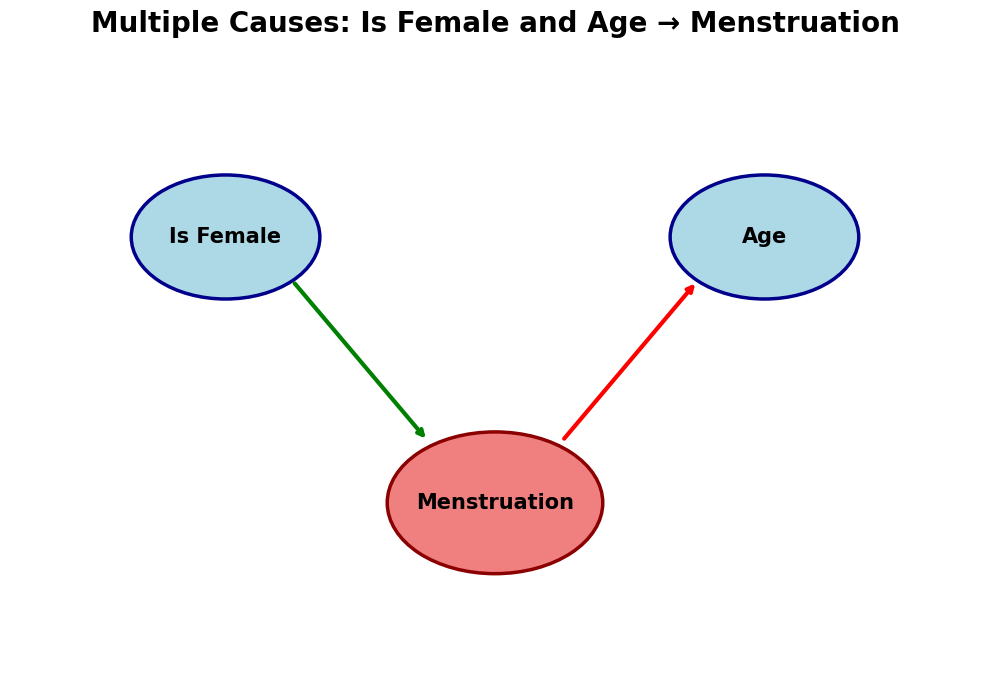

In [53]:
# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Create the DAG
G = nx.DiGraph()
# G.add_edge("Age", "Menstruation")
# G.add_edge("Is Female", "Menstruation")

# Define positions for nodes
pos = {
    "Is Female": (0, 1),
    "Age": (2, 1),
    "Menstruation": (1, -0.5)
}

ax.set_xlim(-0.8, 2.8)
ax.set_ylim(-1.5, 2)
ax.axis('off')
ax.set_title("Multiple Causes: Is Female and Age → Menstruation", 
             fontsize=20, fontweight='bold', pad=20)

# Draw nodes with different colors for causes vs outcome
for node, (x, y) in pos.items():
    if node == "Menstruation":
        color = 'lightcoral'
        edge_color = 'darkred'
        size = 0.4
    elif node == "Age":
        color = 'lightblue'
        edge_color = 'darkblue'
        size = 0.35
    else: 
        color = 'lightblue'
        edge_color = 'darkblue'
        size = 0.35
    
    circle = plt.Circle((x, y), size, color=color, ec=edge_color, linewidth=2.5, zorder=2)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=15, fontweight='bold', zorder=3)

# Draw edges (arrows from causes to effect)
# Smoking -> Lung Cancer
ax.annotate('', xy=(0.75, -0.15), xytext=(0.25, 0.75),
             arrowprops=dict(arrowstyle='->', lw=3, color='green'))

# # Genetics -> Lung Cancer
# ax.annotate('', xy=(1.25, -0.15), xytext=(1.75, 0.75),
#              arrowprops=dict(arrowstyle='->', lw=3, color='darkblue'))

# Genetics -> Lung Cancer
ax.annotate('', xy=(1.25, -0.15), xytext=(1.75, 0.75),
             arrowprops=dict(arrowstyle='<-', lw=3, color='red'))

plt.tight_layout()
print("DAG saved successfully!")
print("\nKey insights:")
print("- Smoking and Genetics are independent causes")
print("- Both directly increase lung cancer risk")
print("- This is a 'collider' structure - lung cancer is the common effect")
print("- Conditioning on lung cancer can create spurious association between smoking and genetics")

Infection DAG saved successfully!


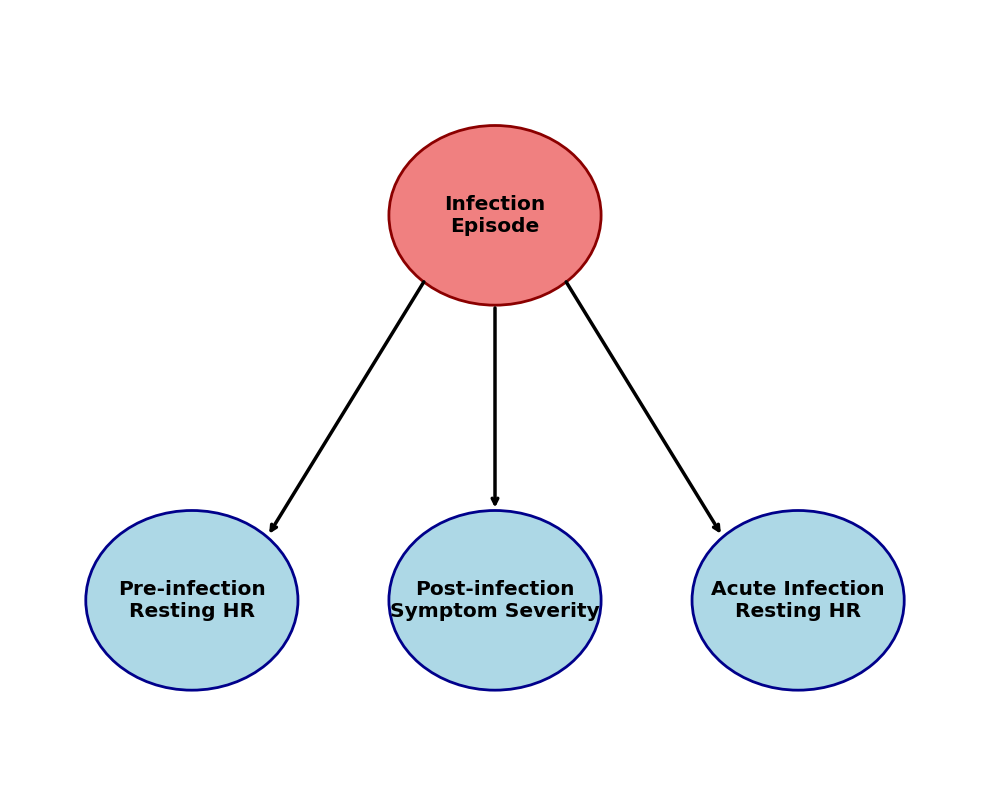

In [44]:
import matplotlib.pyplot as plt
import networkx as nx

# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create the DAG
G = nx.DiGraph()
G.add_edge("Infection\nEpisode", "Pre-infection\nResting HR")
G.add_edge("Infection\nEpisode", "Post-infection\nSymptom Severity")
G.add_edge("Infection\nEpisode", "Acute Infection\nResting HR")

# Define positions for nodes
pos = {
    "Infection\nEpisode": (1, 1),
    "Pre-infection\nResting HR": (0, -0.5),
    "Post-infection\nSymptom Severity": (1, -0.5),
    "Acute Infection\nResting HR": (2, -0.5)
}

ax.set_xlim(-0.6, 2.6)
ax.set_ylim(-1.2, 1.8)
ax.axis('off')

# Draw nodes
for node, (x, y) in pos.items():
    if "Infection\nEpisode" in node:
        color = 'lightcoral'
        edge_color = 'darkred'
    else:
        color = 'lightblue'
        edge_color = 'darkblue'
    
    circle = plt.Circle((x, y), 0.35, color=color, ec=edge_color, linewidth=2, zorder=2)
    ax.add_patch(circle)
    ax.text(x, y, node, ha='center', va='center', fontsize=14.5, fontweight='bold', zorder=3)

# Draw edges
# Infection Episode -> Pre-infection Resting HR
ax.annotate('', xy=(0.25, -0.25), xytext=(0.77, 0.75),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

# Infection Episode -> Post-infection Symptom Severity
ax.annotate('', xy=(1, -0.15), xytext=(1, 0.65),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

# Infection Episode -> Acute Infection Resting HR
ax.annotate('', xy=(1.75, -0.25), xytext=(1.23, 0.75),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

plt.tight_layout()
print("Infection DAG saved successfully!")